Import Libraries & lode the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results.csv')

In [2]:
df.head()

,_id,isPb,wpm,acc,rawWpm,consistency,charStats,mode,mode2,quoteLength,...,punctuation,numbers,language,funbox,difficulty,lazyMode,blindMode,bailedOut,tags,timestamp
0,69569374783db59f598f9b69,NaN,52.40,95.62,52.40,68.94,262;0;0;0,time,60,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1767281524000
1,69563aa7783db59f598cda72,NaN,44.00,86.82,44.00,62.44,220;0;0;0,time,60,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1767258791000
2,69563a5e783db59f598cd881,NaN,49.60,93.70,49.60,58.16,248;0;0;0,time,60,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1767258718000
3,694fd474783db59f595ce163,NaN,50.40,92.70,50.40,63.95,252;0;0;0,time,60,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1766839412000
4,694e1d7d783db59f594fde4c,NaN,54.61,94.81,54.61,70.28,273;0;0;0,time,60,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1766727037000


Basic overview

In [3]:
df.shape

(645, 24)

In [4]:
df.columns

Index(['_id', 'isPb', 'wpm', 'acc', 'rawWpm', 'consistency', 'charStats',
       'mode', 'mode2', 'quoteLength', 'restartCount', 'testDuration',
       'afkDuration', 'incompleteTestSeconds', 'punctuation', 'numbers',
       'language', 'funbox', 'difficulty', 'lazyMode', 'blindMode',
       'bailedOut', 'tags', 'timestamp'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   _id                    645 non-null    object 
 1   isPb                   62 non-null     object 
 2   wpm                    645 non-null    float64
 3   acc                    645 non-null    float64
 4   rawWpm                 645 non-null    float64
 5   consistency            645 non-null    float64
 6   charStats              645 non-null    object 
 7   mode                   645 non-null    object 
 8   mode2                  645 non-null    object 
 9   quoteLength            645 non-null    int64  
 10  restartCount           645 non-null    int64  
 11  testDuration           645 non-null    float64
 12  afkDuration            645 non-null    int64  
 13  incompleteTestSeconds  645 non-null    float64
 14  punctuation            645 non-null    bool   
 15  number

In [6]:
df.describe()

,wpm,acc,rawWpm,consistency,quoteLength,restartCount,testDuration,afkDuration,incompleteTestSeconds,funbox,tags,timestamp
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,0.0,0.0,6.450000e+02
mean,35.775426,91.140357,36.108481,55.444016,-0.996899,0.001550,87.476806,1.420155,0.041426,NaN,NaN,1.736819e+12
std,8.667590,3.409571,8.596890,8.724466,0.078750,0.039375,38.637838,3.431028,1.052099,NaN,NaN,1.148777e+10
min,14.900000,75.000000,15.000000,5.700000,-1.000000,0.000000,15.000000,0.000000,0.000000,NaN,NaN,1.719925e+12
25%,30.000000,89.390000,30.400000,51.110000,-1.000000,0.000000,60.000000,0.000000,0.000000,NaN,NaN,1.728272e+12
50%,35.700000,91.560000,36.000000,56.480000,-1.000000,0.000000,120.000000,0.000000,0.000000,NaN,NaN,1.732982e+12
75%,42.190000,93.540000,42.390000,61.430000,-1.000000,0.000000,120.010000,1.000000,0.000000,NaN,NaN,1.743929e+12
max,57.390000,98.180000,57.390000,75.130000,1.000000,1.000000,264.220000,40.000000,26.720000,NaN,NaN,1.767282e+12


Check the missing values

In [7]:
df.isnull().sum()

_id                        0
isPb                     583
wpm                        0
acc                        0
rawWpm                     0
consistency                0
charStats                  0
mode                       0
mode2                      0
quoteLength                0
restartCount               0
testDuration               0
afkDuration                0
incompleteTestSeconds      0
punctuation                0
numbers                    0
language                   0
funbox                   645
difficulty                 0
lazyMode                   0
blindMode                  0
bailedOut                  0
tags                     645
timestamp                  0
dtype: int64

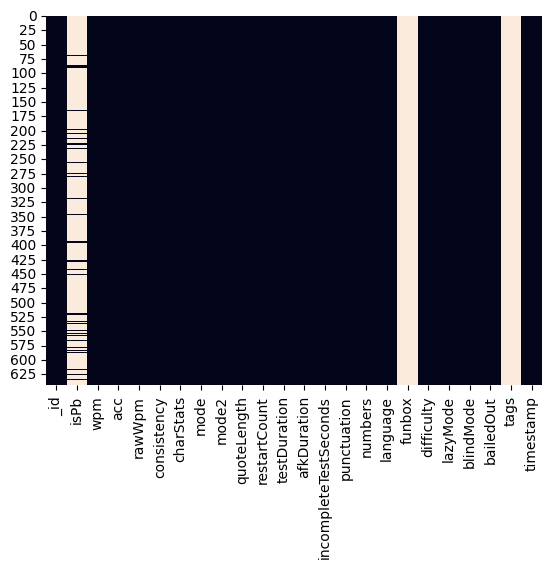

In [8]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.show()

Handle missing or Incorrect Data

In [9]:
# Remove rows with too many NULLs

df = df.dropna(thresh=5)  # Drop rows with less than 5 non-null values

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   _id                    645 non-null    object 
 1   isPb                   62 non-null     object 
 2   wpm                    645 non-null    float64
 3   acc                    645 non-null    float64
 4   rawWpm                 645 non-null    float64
 5   consistency            645 non-null    float64
 6   charStats              645 non-null    object 
 7   mode                   645 non-null    object 
 8   mode2                  645 non-null    object 
 9   quoteLength            645 non-null    int64  
 10  restartCount           645 non-null    int64  
 11  testDuration           645 non-null    float64
 12  afkDuration            645 non-null    int64  
 13  incompleteTestSeconds  645 non-null    float64
 14  punctuation            645 non-null    bool   
 15  number

In [11]:
# Fil missing boolean values

bool_cols = ['isPb', 'punctuation', 'numbers', 'lazyMode', 'blindMode', 'bailedOut']
for col in bool_cols:
    df[col] = df[col].fillna(False)    # find all missing values and replace with False


C:\Users\akhul\AppData\Local\Temp\ipykernel_16328\1499868860.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False)    # find all missing values and replace with False


Convert Data Types

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')  # convert miliseconds based unix timestamp into pandas dataframe format for proper time based analysis

df[['chars', 'errors', 'extra', 'missed']] = df['charStats'].str.split(';', expand=True).astype(int) # split a semicolom separated string column into multiple numeric feature columns

# using single bracket with multiple column names create a toupleKey and cause a error. Multiple columns must using double square brackets

# expand=True: convert the result into separated columuns instade of list
# df = df.drop(columns=['charStats'])  # drop the original column after splitting



Univariate Analysis

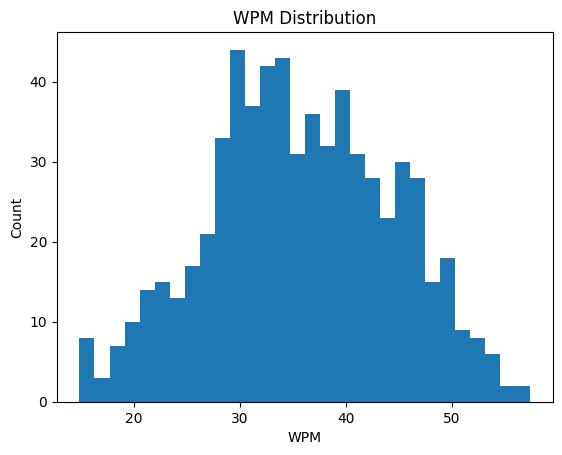

In [13]:
# distrubution of WPM

plt.hist(df['wpm'], bins=30) # bins: how the data range is devided into intevals in an histogram, controling the lavel of detail in the distribution
plt.title("WPM Distribution")
plt.xlabel("WPM")
plt.ylabel("Count")
plt.show()

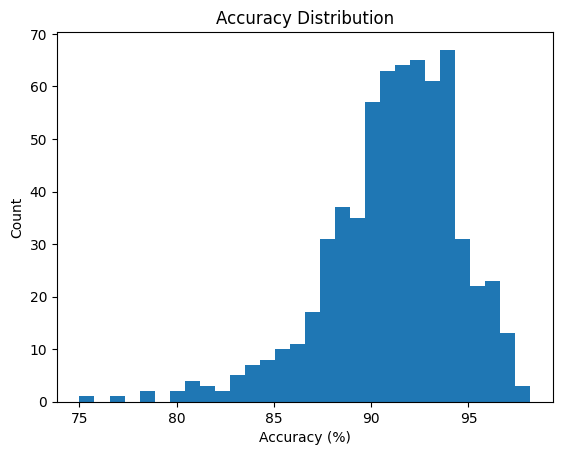

In [14]:
# distribution of Accuracy

plt.hist(df['acc'], bins=30)
plt.title("Accuracy Distribution")
plt.xlabel("Accuracy (%)")
plt.ylabel("Count")
plt.show()


Bivariate analysis

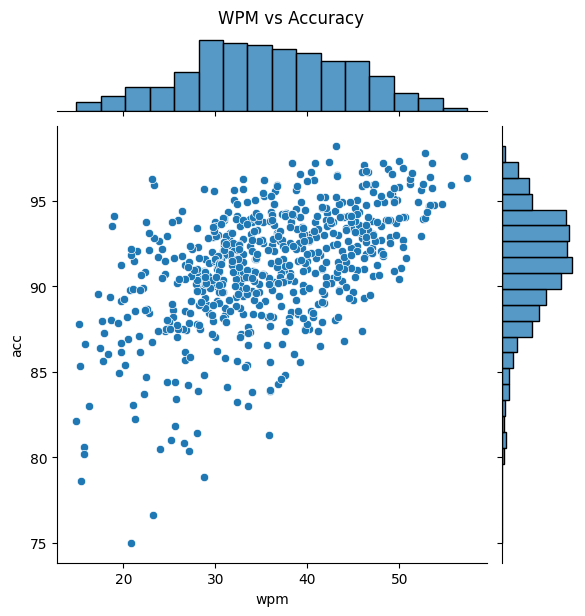

In [15]:
sns.jointplot(x='wpm', y='acc', data=df, kind='scatter')   # scatter + histogram
plt.suptitle("WPM vs Accuracy", y=1.02)
plt.show()

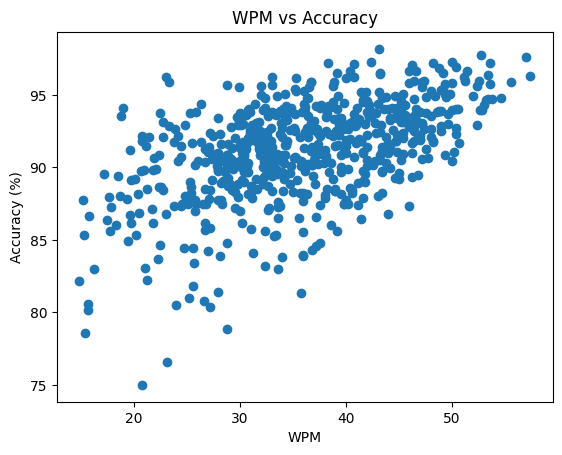

In [16]:
plt.scatter(df['wpm'], df['acc'])
plt.xlabel("WPM")
plt.ylabel("Accuracy (%)")
plt.title("WPM vs Accuracy")
plt.show()

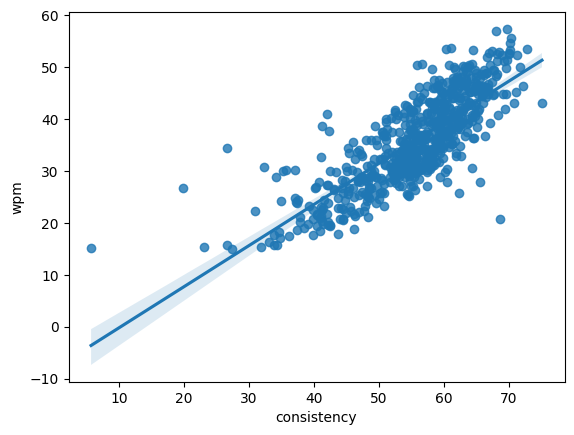

In [17]:
sns.regplot(x = df['consistency'], y = df['wpm'])   # linear relationships and trend identification
plt.show()

Correlation Matrix

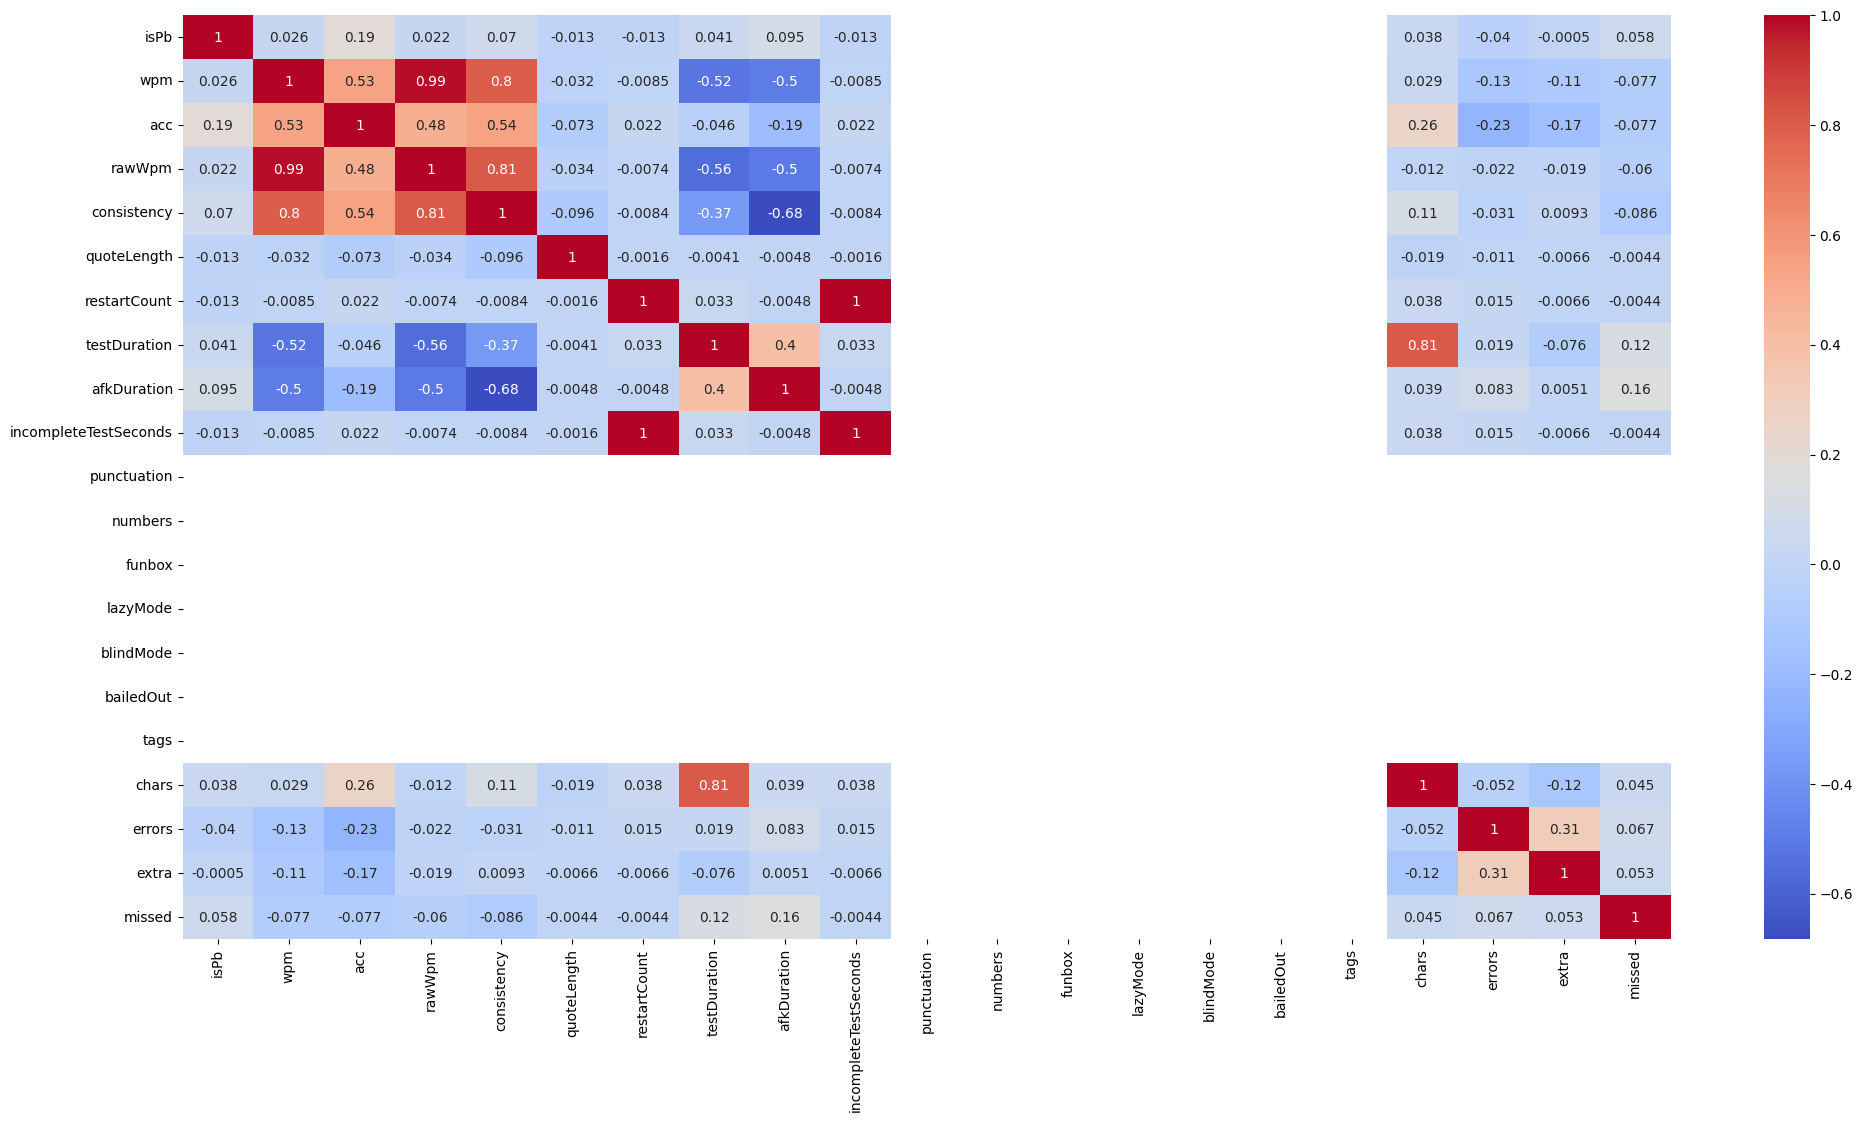

In [18]:
plt.figure(figsize=(24,12))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.show()

<Axes: >

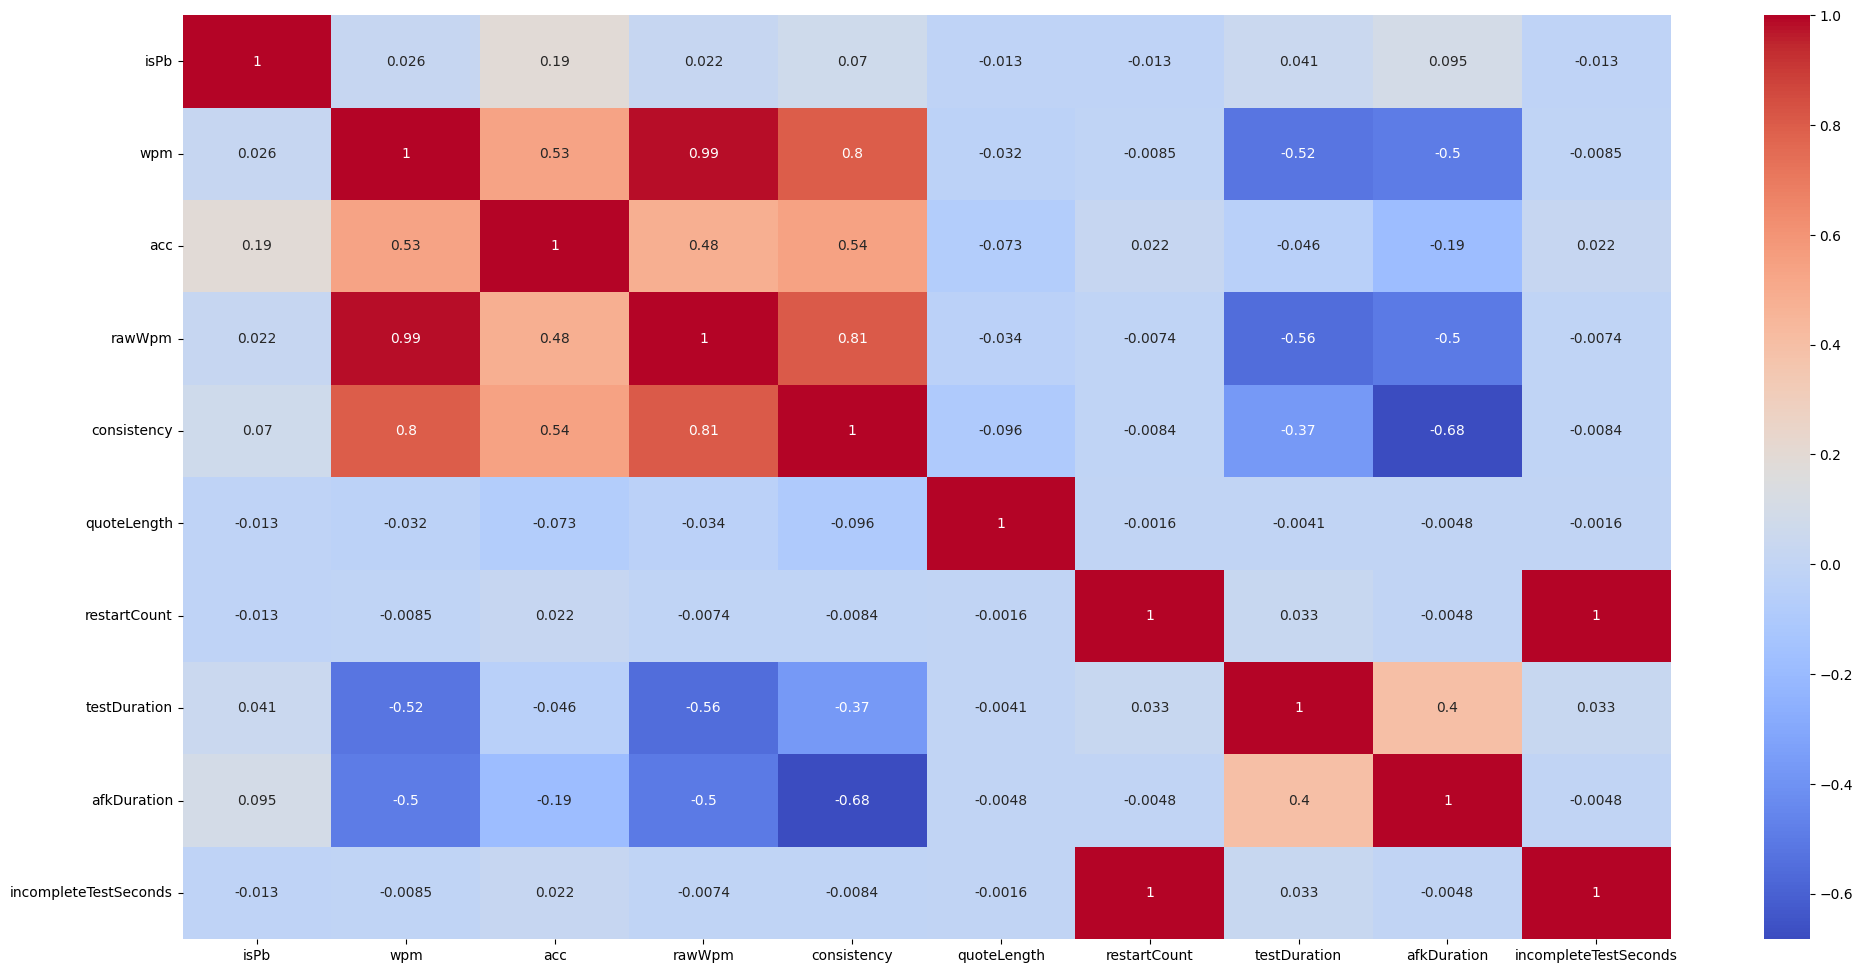

In [19]:
# remove the gap

num_df = df.select_dtypes(include=['int64', 'float64', 'bool'])  # remove string / ID columns
num_df = num_df.loc[:, num_df.nunique()>1]   # remove constant columns
corr = num_df.corr()            # .corr() works only valid numeric data
plt.figure(figsize=(24,12))
sns.heatmap(corr, annot=True, cmap='coolwarm')

Outlier Detection

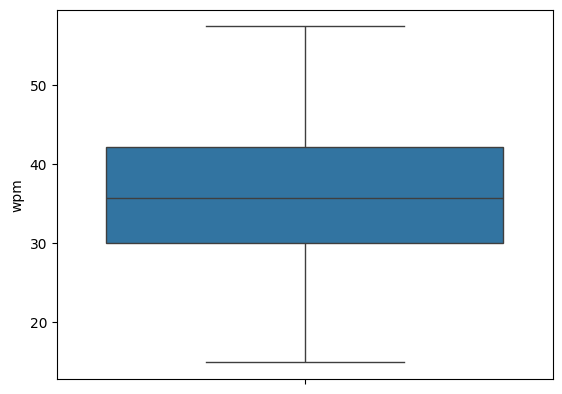

In [20]:
# Boxplot for wpm

sns.boxplot(df['wpm'])
plt.show()

In [21]:
# Identify numerical outliers

Q1 = df['wpm'].quantile(0.25)
Q3 = df['wpm'].quantile(0.75)

IQR = Q3 - Q1     # Interquartile Range
outlier = df[(df['wpm'] < Q1-IQR*1.5) | (df['wpm'] > Q3 + IQR*1.5)]
outlier.head()

,_id,isPb,wpm,acc,rawWpm,consistency,charStats,mode,mode2,quoteLength,...,difficulty,lazyMode,blindMode,bailedOut,tags,timestamp,chars,errors,extra,missed


Time Series Analysis

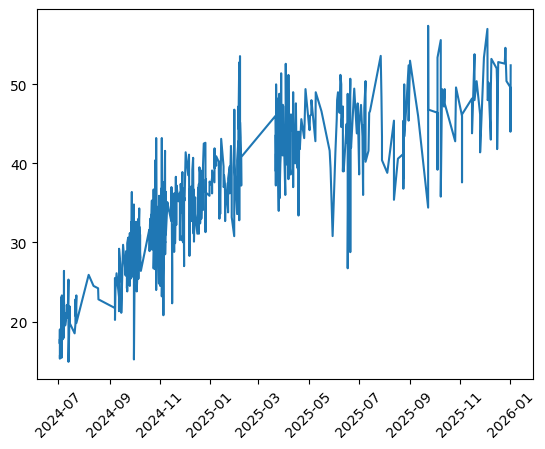

In [22]:
df_sorted = df.sort_values('timestamp')              # take column name as a 'string' not as a column
plt.plot(df_sorted['timestamp'], df_sorted['wpm'])

plt.xticks(rotation=45)  # to avoid overlapping | 0° = overlap,  45° = balanced and readable, 90° = Too vertical
plt.show()

Mode or Catagory analysis

In [23]:
# count of modes
df['mode'].value_counts()

mode
time      638
words       4
custom      2
quote       1
Name: count, dtype: int64

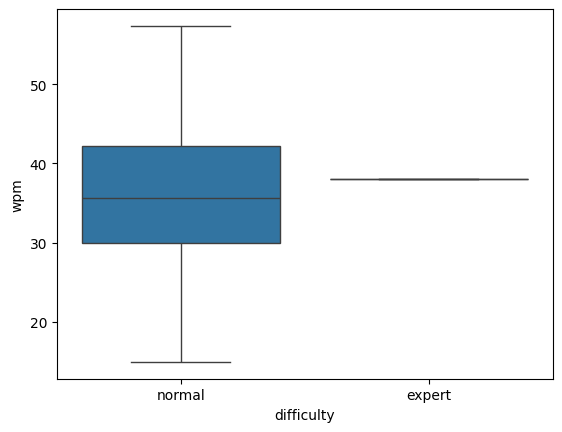

In [24]:
# compare wpm by dificulty

sns.boxplot(x = df['difficulty'], y = df['wpm'])
plt.show()

Save clean dataset

In [25]:
df.to_csv('cleaned_results.csv', index=False)